In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import os
import sys
from GCN import GCN
from GraphSAGE import GraphSAGE
from GAT import GAT

# Import the custom dataset
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from Datasets.garesearch_dataset import GAResearchDataset

from torch_geometric.datasets import HeterophilousGraphDataset
from torch_geometric.loader import DataLoader
import numpy as np
import random
import time
from sklearn.metrics import f1_score, accuracy_score


/home/hice1/pmaji3/scratch/gnn02/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

cuda


In [4]:
args = {
      'device': device,
      'num_layers': 3,
      'hidden_dim': 256,
      'dropout': 0.3,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 0,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 0
  }

In [5]:
## Instantiate the ExperimentTracker
from results_manager import ExperimentTracker

tracker = ExperimentTracker(dataset_name="Amazon Ratings", node_feature_type="FastText")

In [6]:
#dataset = HeterophilousGraphDataset(root ='tmp/Amazon-ratings', name='Amazon-ratings')
#dataset = GAResearchDataset(root ='tmp/amazon-custom', name='amazon')
dataset = GAResearchDataset(root ='tmp/amazon-fasttext-custom', name='amazon-fasttext')

Processing...
Done!


In [7]:
num_features = dataset.num_features
num_classes = dataset.num_classes
num_nodes = dataset[0].num_nodes
num_edges = dataset[0].num_edges

print(f"Number of graphs in dataset: {len(dataset)}")
print(f"Number of features for each node: {num_features}")
print(f"Number of num_classes : {num_classes}")

print(f"Number of num_nodes : {num_nodes}")
print(f"Number of num_edges : {num_edges}")

Number of graphs in dataset: 1
Number of features for each node: 300
Number of num_classes : 5
Number of num_nodes : 24492
Number of num_edges : 186100


In [8]:
# Number of splits available
print(dataset[0].train_mask.shape)
print(dataset[0].test_mask.shape)
print(dataset[0].val_mask.shape)

torch.Size([24492, 10])
torch.Size([24492, 10])
torch.Size([24492, 10])


In [9]:
print(dataset[0].train_mask[:,args['split_idx']])
print(dataset[0].train_mask[:,args['split_idx']].shape)

tensor([False, False,  True,  ..., False,  True, False])
torch.Size([24492])


In [10]:
import numpy as np

labels = dataset.data.y

counts = np.bincount(labels)
print("Class Distribution for Amazon Ratings:")
for i, count in enumerate(counts):
    percentage = (count / len(labels)) * 100
    print(f"Rating {i}: {count:>6} samples ({percentage:5.2f}%)")


Class Distribution for Amazon Ratings:
Rating 0:   6560 samples (26.78%)
Rating 1:   9010 samples (36.79%)
Rating 2:   5678 samples (23.18%)
Rating 3:   2183 samples ( 8.91%)
Rating 4:   1061 samples ( 4.33%)


/tmp/ipykernel_2733814/1619669783.py:3: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  labels = dataset.data.y


In [11]:
def train(model, data, optimizer, criterion):
    """
    one training epoch
    model -  GNN (GCNConv or GraphSAGE)
    data - Entire Graph Dataset i.e. dataset[0]
    optimizer - algorithm that updates model weights (Adam, SGD, etc.)
    criterion - loss function (often BCEWithLogitsLoss for the PPI dataset)
    """
    #Training mode
    model.train()
    #TODO: Move the data to device outside the training loop
    #data = data.to(device)
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    split_idx = args['split_idx']
    loss = criterion(out[data.train_mask[:,split_idx]], data.y[data.train_mask[:,split_idx]])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def test(model, data, mask, return_preds=False):
    """
    data: dataset[0] - 1 entire graph composed of all labeled train, test, val
    mask: array of [True, False, ....]
    """
    #switch to evaluation mode
    model.eval()
    # ys: Ground Truth Labels, preds: model predictions across all batches
    ys, preds = [], []

    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out[mask].argmax(dim=1).cpu().numpy()
    y = data.y[mask].cpu().numpy()
    
    #macro - how model handles small classes
    f1 = f1_score(y, pred, average='macro', zero_division=0)
    acc = accuracy_score(y, pred)
    if return_preds:
        return f1, acc, y, pred
    return f1, acc
        

In [13]:
def train_and_evaluate(model, data, optimizer, scheduler, criterion, model_name, epochs=100):
    best_val_f1 = 0
    train_losses, val_f1s, val_accs, test_f1s, test_accs = [],[],[],[],[]
    training_time = 0

    for epoch in range(1, epochs+1):
        start_time = time.time()

        loss = train(model, data, optimizer, criterion)
        
        if scheduler:
            scheduler.step()

        epoch_time = time.time() - start_time
        training_time += epoch_time

        split_idx = args['split_idx']
        val_f1, val_acc = test(model, data, data.val_mask[:,split_idx])
        test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])

        train_losses.append(loss)
        val_f1s.append(val_f1)
        test_f1s.append(test_f1)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model_gcn.pth')

        tracker.log_epoch(model_name=model_name, epoch=epoch, loss=loss, val_f1=val_f1, val_acc=val_acc)
        if epoch % 10 == 0:
            print(f"Epoch: {epoch:03d}, "
                f"Loss: {loss:.4f}, "
                f"Val F1: {val_f1:.4f},"
                f"Val Acc: {val_acc:.4f}, "
                f"Time: {epoch_time:.2f}s"
                )


    model.load_state_dict(torch.load('best_model_gcn.pth', map_location=device))
    test_f1, test_acc, y_true, y_pred = test(model, data, data.test_mask[:,split_idx], return_preds=True)
    #test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=range(5), yticklabels=range(5))
    plt.title('Normalized Confusion Matrix: Roman Empire Syntactic Roles')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()
    
    tracker.save_results(
        model_name=model_name, 
        test_f1=test_f1, 
        test_acc=test_acc,
        params=args # Assuming 'args' contains your hyperparams
    )
    
    return model, train_losses, val_f1s, test_f1s, training_time

In [14]:
def build_optimizer(args, params):
    
    filter_fn = filter(lambda p : p.requires_grad, params)
    weight_decay = args['weight_decay']
    if args['opt'] == 'adam':
        optimizer = torch.optim.Adam(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'sgd':
        optimizer = torch.optim.SGD(filter_fn, lr=args['lr'], momentum=0.95, weight_decay=weight_decay)
    elif args['opt'] == 'rmsprop':
        optimizer = torch.optim.RMSprop(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'adagrad':
        optimizer = torch.optim.Adagrad(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    if args['opt_scheduler'] == 'none':
        return None, optimizer
    elif args['opt_scheduler'] == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args['opt_decay_step'], gamma=args['opt_decay_rate'])
    elif args['opt_scheduler'] == 'cos':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args['opt_restart'])
    return scheduler, optimizer

In [15]:
import matplotlib.pyplot as plt
def plot_results(results, title, label, ylabel):
    plt.figure(figsize=(3,2))
    epochs = range(1, len(results)+1)
    plt.plot(epochs, results, label = label)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

In [16]:
def gcn_run():
    model = GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN','F1 Score')


Training GCN
Epoch: 010, Loss: 1.3531, Val F1: 0.0846,Val Acc: 0.2681, Time: 0.01s
Epoch: 020, Loss: 1.2469, Val F1: 0.0848,Val Acc: 0.2683, Time: 0.01s
Epoch: 030, Loss: 1.1932, Val F1: 0.1185,Val Acc: 0.2987, Time: 0.01s
Epoch: 040, Loss: 1.1461, Val F1: 0.1873,Val Acc: 0.3867, Time: 0.01s
Epoch: 050, Loss: 1.0973, Val F1: 0.2081,Val Acc: 0.4085, Time: 0.01s
Epoch: 060, Loss: 1.0486, Val F1: 0.2275,Val Acc: 0.4265, Time: 0.01s
Epoch: 070, Loss: 1.0064, Val F1: 0.2648,Val Acc: 0.4461, Time: 0.01s
Epoch: 080, Loss: 0.9672, Val F1: 0.3041,Val Acc: 0.4588, Time: 0.01s
Epoch: 090, Loss: 0.9394, Val F1: 0.3466,Val Acc: 0.4667, Time: 0.01s
Epoch: 100, Loss: 0.9118, Val F1: 0.3638,Val Acc: 0.4700, Time: 0.01s
Test F1: 0.3584
Test Accuracy: 0.4672


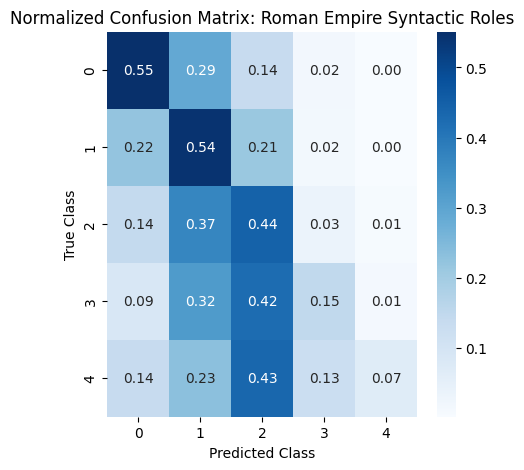

GCN results saved using FastText features.
Training Time 1.7806453704833984


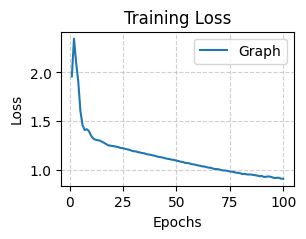

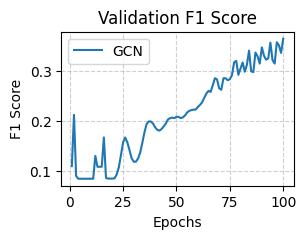

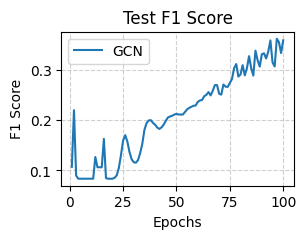

In [17]:
gcn_run()

In [18]:
def graphSage_run():
    model = GraphSAGE(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training Graph SAGE")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data,
        optimizer,
        scheduler, 
        criterion, 
        model_name="GraphSAGE",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GraphSAGE','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GraphSAGE','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GraphSAGE','F1 Score')


Training Graph SAGE
Epoch: 010, Loss: 1.3556, Val F1: 0.1923,Val Acc: 0.3855, Time: 0.01s
Epoch: 020, Loss: 1.2371, Val F1: 0.1362,Val Acc: 0.3134, Time: 0.01s
Epoch: 030, Loss: 1.1312, Val F1: 0.2243,Val Acc: 0.4140, Time: 0.01s
Epoch: 040, Loss: 1.0114, Val F1: 0.2729,Val Acc: 0.4183, Time: 0.01s
Epoch: 050, Loss: 0.8543, Val F1: 0.3597,Val Acc: 0.4661, Time: 0.01s
Epoch: 060, Loss: 0.6795, Val F1: 0.4152,Val Acc: 0.5020, Time: 0.01s
Epoch: 070, Loss: 0.5744, Val F1: 0.4443,Val Acc: 0.5131, Time: 0.01s
Epoch: 080, Loss: 0.4136, Val F1: 0.4601,Val Acc: 0.5310, Time: 0.01s
Epoch: 090, Loss: 0.3174, Val F1: 0.4705,Val Acc: 0.5325, Time: 0.01s
Epoch: 100, Loss: 0.2374, Val F1: 0.4881,Val Acc: 0.5465, Time: 0.01s
Test F1: 0.4898
Test Accuracy: 0.5440


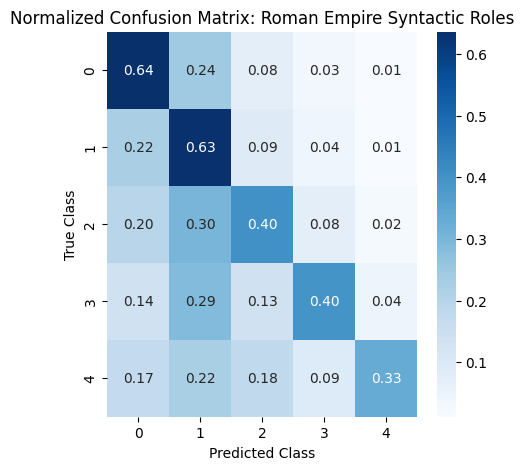

GRAPHSAGE results saved using FastText features.
Training Time 1.2349755764007568


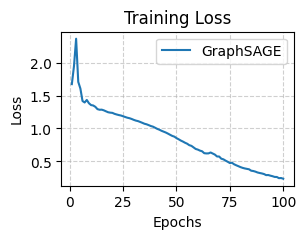

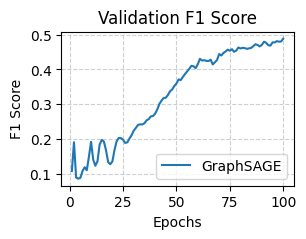

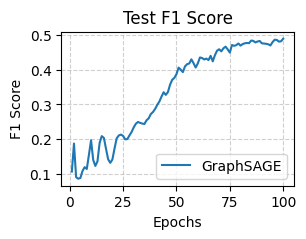

In [19]:
graphSage_run()

In [20]:
def gat_run():
    model = GAT(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'],
                heads=args['heads'],
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training GAT")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GAT",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GAT','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GAT','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GAT','F1 Score')


Training GAT
Epoch: 010, Loss: 1.5792, Val F1: 0.1084,Val Acc: 0.3718, Time: 0.03s
Epoch: 020, Loss: 1.3764, Val F1: 0.1088,Val Acc: 0.3720, Time: 0.03s
Epoch: 030, Loss: 1.3273, Val F1: 0.1568,Val Acc: 0.3855, Time: 0.03s
Epoch: 040, Loss: 1.2918, Val F1: 0.1687,Val Acc: 0.3849, Time: 0.03s
Epoch: 050, Loss: 1.2534, Val F1: 0.2384,Val Acc: 0.4165, Time: 0.03s
Epoch: 060, Loss: 1.2251, Val F1: 0.2624,Val Acc: 0.4310, Time: 0.03s
Epoch: 070, Loss: 1.1893, Val F1: 0.2797,Val Acc: 0.4361, Time: 0.03s
Epoch: 080, Loss: 1.1534, Val F1: 0.3034,Val Acc: 0.4551, Time: 0.03s
Epoch: 090, Loss: 1.1223, Val F1: 0.3403,Val Acc: 0.4641, Time: 0.03s
Epoch: 100, Loss: 1.0879, Val F1: 0.3460,Val Acc: 0.4718, Time: 0.03s
Test F1: 0.3497
Test Accuracy: 0.4572


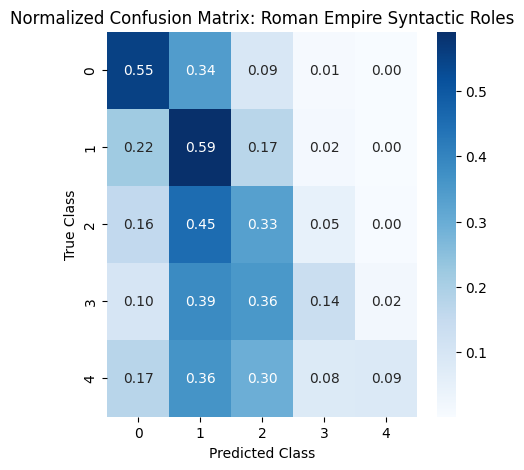

GAT results saved using FastText features.
Training Time 3.2358686923980713


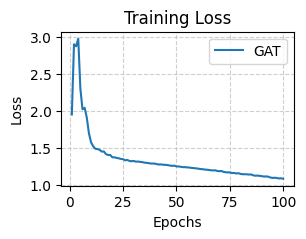

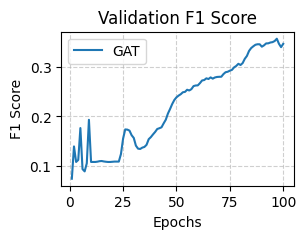

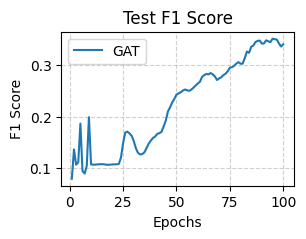

In [21]:
gat_run()

In [22]:
def gat_run():
    model = GAT(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'],
                heads=args['heads'],
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training GAT")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GAT",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GAT','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GAT','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GAT','F1 Score')


Training GAT
Epoch: 010, Loss: 1.4806, Val F1: 0.0961,Val Acc: 0.2715, Time: 0.03s
Epoch: 020, Loss: 1.3570, Val F1: 0.1787,Val Acc: 0.3920, Time: 0.03s
Epoch: 030, Loss: 1.3187, Val F1: 0.1252,Val Acc: 0.3751, Time: 0.03s
Epoch: 040, Loss: 1.2840, Val F1: 0.2182,Val Acc: 0.4010, Time: 0.03s
Epoch: 050, Loss: 1.2610, Val F1: 0.2267,Val Acc: 0.4222, Time: 0.03s
Epoch: 060, Loss: 1.2363, Val F1: 0.2691,Val Acc: 0.4353, Time: 0.03s
Epoch: 070, Loss: 1.2103, Val F1: 0.2828,Val Acc: 0.4392, Time: 0.03s


Epoch: 080, Loss: 1.1759, Val F1: 0.3079,Val Acc: 0.4535, Time: 0.03s
Epoch: 090, Loss: 1.1482, Val F1: 0.3168,Val Acc: 0.4620, Time: 0.03s
Epoch: 100, Loss: 1.1170, Val F1: 0.3380,Val Acc: 0.4616, Time: 0.03s
Test F1: 0.3356
Test Accuracy: 0.4481


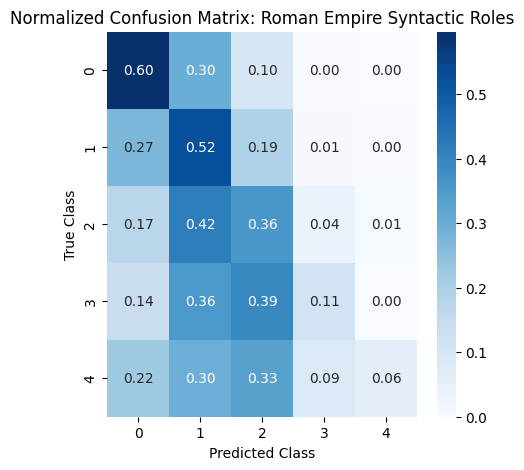

GAT results saved using FastText features.
Training Time 3.2204458713531494


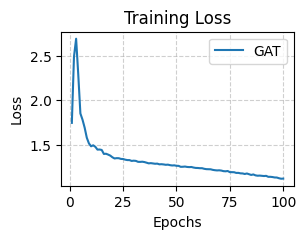

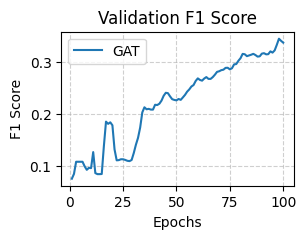

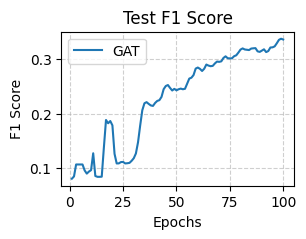

In [23]:
gat_run()

In [24]:
from GCN2 import GCN2

In [25]:
args = {
      'device': device,
      'num_layers': 10,
      'hidden_dim': 256,
      'dropout': 0.5,
      'lr': 0.001,
      'epochs': 400,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [26]:
def gcn2_run():
    model = GCN2(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout'], alpha=args['alpha'], theta=args['theta']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN2",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN2','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN2','F1 Score')


Training GCN
Epoch: 010, Loss: 1.5370, Val F1: 0.0853,Val Acc: 0.2709, Time: 0.06s
Epoch: 020, Loss: 1.4267, Val F1: 0.0853,Val Acc: 0.2709, Time: 0.06s
Epoch: 030, Loss: 1.3800, Val F1: 0.0853,Val Acc: 0.2709, Time: 0.06s
Epoch: 040, Loss: 1.3350, Val F1: 0.0853,Val Acc: 0.2709, Time: 0.06s
Epoch: 050, Loss: 1.2999, Val F1: 0.0853,Val Acc: 0.2709, Time: 0.06s
Epoch: 060, Loss: 1.2764, Val F1: 0.0853,Val Acc: 0.2709, Time: 0.06s
Epoch: 070, Loss: 1.2528, Val F1: 0.0864,Val Acc: 0.2715, Time: 0.06s
Epoch: 080, Loss: 1.2318, Val F1: 0.1037,Val Acc: 0.2803, Time: 0.06s
Epoch: 090, Loss: 1.2206, Val F1: 0.1660,Val Acc: 0.3116, Time: 0.06s
Epoch: 100, Loss: 1.2145, Val F1: 0.2718,Val Acc: 0.3987, Time: 0.06s
Epoch: 110, Loss: 1.1959, Val F1: 0.2975,Val Acc: 0.4192, Time: 0.06s
Epoch: 120, Loss: 1.1815, Val F1: 0.3138,Val Acc: 0.4363, Time: 0.06s
Epoch: 130, Loss: 1.1769, Val F1: 0.3134,Val Acc: 0.4369, Time: 0.06s
Epoch: 140, Loss: 1.1656, Val F1: 0.3130,Val Acc: 0.4428, Time: 0.06s
Epoch: 

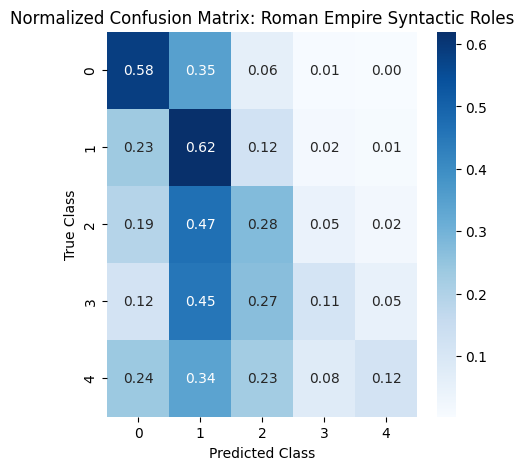

GCN2 results saved using FastText features.
Training Time 25.384949922561646


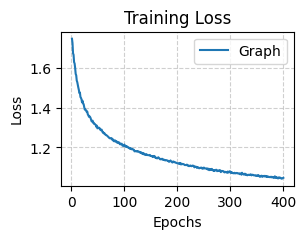

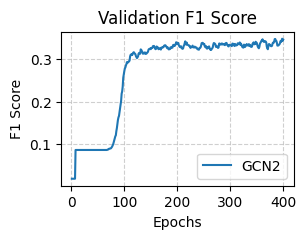

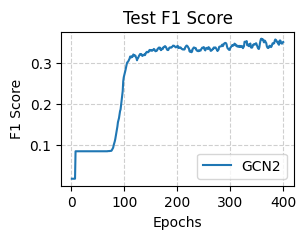

In [27]:
gcn2_run()

In [28]:
from H2GCN import H2GCN

In [29]:
args = {
      'device': device,
      'num_layers': 3, #Not applicable to H2GCN
      'hidden_dim': 300,
      'dropout': 0.5,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [30]:
def h2GCN_run():
    model = H2GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training H2GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="H2GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'H2GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'H2GCN','F1 Score')


Training H2GCN
Epoch: 010, Loss: 1.3117, Val F1: 0.1091,Val Acc: 0.3628, Time: 0.02s
Epoch: 020, Loss: 1.2107, Val F1: 0.1060,Val Acc: 0.2873, Time: 0.02s
Epoch: 030, Loss: 1.1154, Val F1: 0.0853,Val Acc: 0.2709, Time: 0.02s
Epoch: 040, Loss: 1.0454, Val F1: 0.0853,Val Acc: 0.2709, Time: 0.02s
Epoch: 050, Loss: 0.9495, Val F1: 0.0860,Val Acc: 0.2715, Time: 0.02s
Epoch: 060, Loss: 0.8631, Val F1: 0.1139,Val Acc: 0.2871, Time: 0.02s
Epoch: 070, Loss: 0.8431, Val F1: 0.2593,Val Acc: 0.3879, Time: 0.02s
Epoch: 080, Loss: 0.7864, Val F1: 0.3757,Val Acc: 0.4514, Time: 0.02s
Epoch: 090, Loss: 0.7502, Val F1: 0.4114,Val Acc: 0.4716, Time: 0.02s
Epoch: 100, Loss: 0.7419, Val F1: 0.4083,Val Acc: 0.4896, Time: 0.02s
Test F1: 0.4212
Test Accuracy: 0.4977


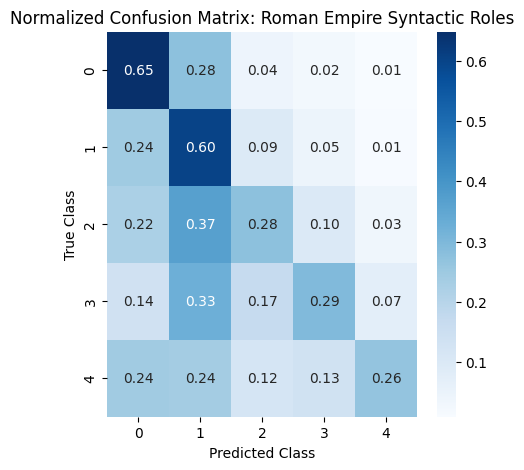

H2GCN results saved using FastText features.
Training Time 1.5186347961425781


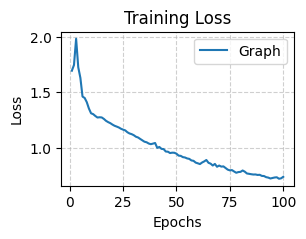

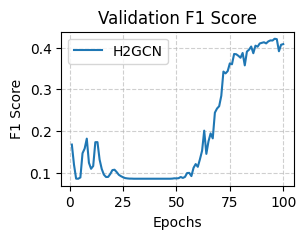

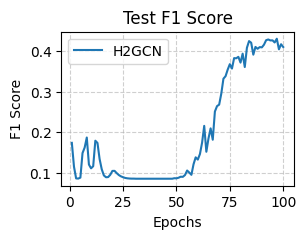

In [31]:
h2GCN_run()